In [1]:
from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.trainers import WordLevelTrainer
from tokenizers.pre_tokenizers import Whitespace

from torch.utils.data import Dataset, DataLoader , random_split
# from torch.utils.data import DataLoader, IterableDataset as TorchIterableDataset
import torch
import torch.nn as nn
import math
import numpy as np
import matplotlib.pyplot as plt

from configurations import create_fig, set_font_sizes, apply_general_styles
apply_general_styles()
# full size dataset tiny stories  = 2119719
# max sequence leng >~ 267

c:\Users\crise\OneDrive - SISSA\Documents\SISSA\SISSA 2nd YEAR\Transformers\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1

In [57]:
cache_dir = "~/.cache/huggingface/datasets/"
import os
cache_dir = os.path.expanduser(cache_dir)
cache_dir

'C:\\Users\\crise/.cache/huggingface/datasets/'

In [2]:
# Download just a fraction of the dataset 
dataset = load_dataset("roneneldan/TinyStories", split="train[:20]")
print(len(dataset))

20


In [5]:
print(dataset[1]['text'])

Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.

One day, Beep was driving in the park when he saw a big tree. The tree had many leaves that were falling. Beep liked how the leaves fall and wanted to play with them. Beep drove under the tree and watched the leaves fall on him. He laughed and beeped his horn.

Beep played with the falling leaves all day. When it was time to go home, Beep knew he needed more fuel. He went to the fuel place and got more healthy fuel. Now, Beep was ready to go fast and play again the next day. And Beep lived happily ever after.


In [269]:
def get_all_sentences(ds):
    for item in ds:
        yield item['text']

for item in get_all_sentences(dataset):
    print(1,item[:200])
    # break

1 One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on
1 Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.

One day, 
1 One day, a little fish named Fin was swimming near the shore. He saw a big crab and wanted to be friends. "Hi, I am Fin. Do you want to play?" asked the little fish. The crab looked at Fin and said, "
1 Once upon a time, in a land full of trees, there was a little cherry tree. The cherry tree was very sad because it did not have any friends. All the other trees were big and strong, but the cherry tre
1 Once upon a time, there was a little girl named Lily. Lily liked to pretend she was a popular princess. She lived in a big castle with her best friends, a cat and a dog.

One day, while 

In [9]:
def get_all_sentences(ds):
    for item in ds:
        yield item['text']

tokenizer = Tokenizer(WordLevel(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()
trainer = WordLevelTrainer(special_tokens=["[UNK]", "[PAD]", "[SOS]", "[EOS]"], min_frequency=2)
tokenizer.train_from_iterator(get_all_sentences(dataset), trainer=trainer)

In [ ]:
text = 'Once upon a time'
 # Tokenize text
tokens = tokenizer.encode(text).ids
tokenss

[53, 58, 8, 32]

In [38]:

# class NextTokenDataset(TorchIterableDataset):
#     """Dataset for next-token prediction from a single text source."""
    
#     def __init__(self, ds, tokenizer, seq_len):
#         super().__init__()
#         self.ds = ds
#         self.tokenizer = tokenizer
#         self.seq_len = seq_len
        
#         # Get special token IDs
#         self.sos_id = tokenizer.token_to_id("[SOS]")
#         self.eos_id = tokenizer.token_to_id("[EOS]")
#         self.pad_id = tokenizer.token_to_id("[PAD]")
    
#     def __len__(self):
#         return len(self.ds)
    
#     def __getitem__(self, idx):
#         text = self.ds[idx]['text']
        
#         # Tokenize text
#         tokens = self.tokenizer.encode(text).ids
        
#         # Skip if too short
#         if len(tokens) < 2:
#             return None
        
#         # Truncate if too long (with room for SOS and EOS)
#         max_content_len = self.seq_len - 2
#         if len(tokens) > max_content_len:
#             tokens = tokens[:max_content_len]
        
#         # Create input and target sequences
#         # Input: [SOS] + tokens
#         # Target: tokens + [EOS]
#         num_padding = self.seq_len - len(tokens) - 2
        
#         if num_padding < 0:
#             raise ValueError(f"Text too long: {len(tokens)} tokens > {max_content_len}")
        
#         # Input sequence (context): [SOS] + text_tokens + [PAD]*
#         encoder_input = torch.cat([
#             torch.tensor([self.sos_id], dtype=torch.int64),
#             torch.tensor(tokens, dtype=torch.int64),
#             torch.tensor([self.pad_id] * num_padding, dtype=torch.int64),
#         ])
        
#         # Target sequence (what we want to predict): text_tokens + [EOS] + [PAD]*
#         label = torch.cat([
#             torch.tensor(tokens, dtype=torch.int64),
#             torch.tensor([self.eos_id], dtype=torch.int64),
#             torch.tensor([self.pad_id] * (num_padding), dtype=torch.int64),
#         ])
        
#         # Create attention mask (0 for padding, 1 for real tokens)
#         # Shape: (1, 1, seq_len) for broadcasting with attention
#         attention_mask = (encoder_input != self.pad_id).unsqueeze(0).unsqueeze(0).int()
        
#         assert encoder_input.size(0) == self.seq_len
#         assert label.size(0) == self.seq_len
        
#         return {
#             "encoder_input": encoder_input,      # (seq_len): context to feed to model
#             "label": label,                      # (seq_len): target next-token sequence
#             "attention_mask": attention_mask,    # (1, 1, seq_len): mask padding positions
#             "text": text,                        # (str): original text for debugging
#         }


In [69]:
tokenizer.token_to_id("[PAD]")
tokenizer.id_to_token(7)

'and'

# 2

In [99]:
class InputEmbeddings(nn.Module):

    def __init__(self, d_model: int, vocab_size: int) -> None:
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x):
        # (batch, seq_len) --> (batch, seq_len, d_model)
        # Multiply by sqrt(d_model) to scale the embeddings according to the paper
        return self.embedding(x) * math.sqrt(self.d_model)
    
class PositionalEncoding(nn.Module):

    def __init__(self, d_model: int, seq_len: int, dropout: float) -> None:
        super().__init__()
        self.d_model = d_model
        self.seq_len = seq_len
        self.dropout = nn.Dropout(dropout)
        # Create a matrix of shape (seq_len, d_model)
        pe = torch.zeros(seq_len, d_model)
        # Create a vector of shape (seq_len)
        position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1) # (seq_len, 1)
        # Create a vector of shape (d_model)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)) # (d_model / 2)
        # Apply sine to even indices
        pe[:, 0::2] = torch.sin(position * div_term) # sin(position * (10000 ** (2i / d_model))
        # Apply cosine to odd indices
        pe[:, 1::2] = torch.cos(position * div_term) # cos(position * (10000 ** (2i / d_model))
        # Add a batch dimension to the positional encoding
        pe = pe.unsqueeze(0) # (1, seq_len, d_model)
        # Register the positional encoding as a buffer
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + (self.pe[:, :x.shape[1], :]).requires_grad_(False) # (batch, seq_len, d_model)
        return self.dropout(x)
    
class AttentionLayer(nn.Module):
    def __init__(self,d_model:int,seq_len:int,dropout:float,rank:int=None) -> None:
        super().__init__()
        self.d_model=d_model
        self.seq_len=seq_len
        self.dropout=nn.Dropout(dropout)
        
        # Low-rank factorization: W = w1 @ w2.T
        # If rank is None, use full rank (original behavior)
        self.rank = rank if rank is not None else d_model
        self.w1 = nn.Linear(d_model, self.rank, bias=False)
        self.w2 = nn.Linear(d_model, self.rank, bias=False)
    
    def forward(self,x,mask):
        # x: (batch, seq_len, d_model)

        # Efficient computation: x @ W @ x.T = (x @ w1) @ (x @ w2).T
        # Instead of: x @ (w1 @ w2.T) @ x.T
        
        proj_left = self.w1(x)   # (batch, seq_len, rank) - cheaper!
        proj_right = self.w2(x)  # (batch, seq_len, rank)
        
        # Compute attention scores efficiently
        attention_scores = proj_left @ proj_right.transpose(-2, -1) / math.sqrt(self.d_model)
        # (batch, seq_len, rank) @ (batch, rank, seq_len) = (batch, seq_len, seq_len)
        
        if mask is not None:
            attention_scores = attention_scores.masked_fill(mask == 0, -1e9) 
        
        attention_scores = torch.softmax(attention_scores, dim=-1)  # (batch, seq_len, seq_len)
        return attention_scores @ x  # (batch, seq_len, d_model)

class SimpleTransformer(nn.Module):
    def __init__(self, d_model:int, vocab_size:int, seq_len:int, dropout:float=0.1,rank:int=None) -> None:
        super().__init__()
        self.d_model=d_model
        self.vocab_size=vocab_size
        self.seq_len=seq_len
        self.dropout=dropout
        
        self.input_embeddings = InputEmbeddings(d_model,vocab_size)
        self.positional_encoding = PositionalEncoding(d_model,seq_len,dropout)
        self.attention_layer = AttentionLayer(d_model,seq_len,dropout,rank)
    
    def forward(self,encoder_input,attention_mask):
        # encoder_input: (batch, seq_len)        
        e = self.input_embeddings(encoder_input)  # (batch, seq_len, d_model)
        x = self.positional_encoding(e)  # (batch, seq_len, d_model)
        x = self.attention_layer(x,attention_mask)  # (batch, seq_len, d_model)
        x = x + e # (batch, seq_len, d_model)
        x = torch.matmul(x, self.input_embeddings.embedding.weight.t())  # (batch, seq_len, vocab_size)
        
        return x  # (batch, seq_len, vocab_size)

In [3]:
def get_all_sentences(ds):
    for item in ds:
        yield item['text']

def build_tokenizer(raw_dataset):
    tokenizer = Tokenizer(WordLevel(unk_token="[UNK]"))
    tokenizer.pre_tokenizer = Whitespace()
    trainer = WordLevelTrainer(special_tokens=["[UNK]", "[PAD]", "[SOS]", "[EOS]"], min_frequency=2)
    tokenizer.train_from_iterator(get_all_sentences(raw_dataset), trainer=trainer)
    return tokenizer

In [123]:
class NextTokenDataset(Dataset):
    """Dataset for next-token prediction from a single text source."""
    
    def __init__(self, raw_dataset, tokenizer, seq_len):
        super().__init__()
        self.ds = raw_dataset
        self.tokenizer = tokenizer
        self.seq_len = seq_len
        
        # Get special token IDs
        self.sos_id = tokenizer.token_to_id("[SOS]")
        self.eos_id = tokenizer.token_to_id("[EOS]")
        self.pad_id = tokenizer.token_to_id("[PAD]")
    
    def __len__(self):
        return len(self.ds)
    
    def __getitem__(self, idx):
        text = self.ds[idx]['text']
        
        # Tokenize text
        tokens = self.tokenizer.encode(text).ids
        
        # Skip if too short
        if len(tokens) < 2:
            return None
        
        # Truncate if too long (with room for SOS and EOS)
        max_content_len = self.seq_len - 1
        if len(tokens) > max_content_len:
            tokens = tokens[:max_content_len]
        
        # Create input and target sequences
        # Input: [SOS] + tokens + [PAD]*
        # Target: tokens + [EOS] + [PAD]*
        num_padding = self.seq_len - len(tokens) - 1
        
        if num_padding < 0:
            raise ValueError(f"Text too long: {len(tokens)} tokens > {max_content_len}")
        
        # Input sequence (context): [SOS] + text_tokens + [PAD]*
        input = torch.cat([
            torch.tensor([self.sos_id], dtype=torch.int64),
            torch.tensor(tokens, dtype=torch.int64),
            torch.tensor([self.pad_id] * num_padding, dtype=torch.int64),
        ])
        
        # Target sequence (what we want to predict): text_tokens + [EOS] + [PAD]*
        label = torch.cat([
            torch.tensor(tokens, dtype=torch.int64),
            torch.tensor([self.eos_id], dtype=torch.int64),
            torch.tensor([self.pad_id] * (num_padding), dtype=torch.int64),
        ])
        
        # pad mask: True for real tokens, False for PAD
        pad_mask = (input != self.pad_id).unsqueeze(-1)  # ( seq_len, 1) boolean
        pad_mask = pad_mask.bool()

        # causal mask: lower triangular (allow attend to <= position)
        causal_mask = torch.tril(torch.ones((self.seq_len, self.seq_len), dtype=torch.bool))  # ( seq_len, seq_len)

        # combine to (1, seq_len, seq_len): allow only real tokens and past
        attention_mask = pad_mask & causal_mask  # (1, seq_len, seq_len), boolean
            
        assert input.size(0) == self.seq_len
        assert label.size(0) == self.seq_len
        
        return {
            "input": input,                      # (seq_len): context to feed to model
            "label": label,                      # (seq_len): target next-token sequence
            "attention_mask": attention_mask,    # (1, seq_len)&( seq_len, seq_len) pad and causal mask 
            "text": text,                        # (str): original text for debugging
        }
    

def get_dataloader(config):
    # Load the dataset 
    raw_dataset = load_dataset(config['datasource'], split='train[:{}]'.format(config['dataset_size']))
    # Build tokenizer
    tokenizer = build_tokenizer(raw_dataset)
    
    # Split dataset into train and validation sets
    train_size = int(config['train_fraction'] * len(raw_dataset))
    val_size = len(raw_dataset) - train_size
    raw_train_ds , raw_val_ds = random_split(raw_dataset,[train_size,val_size])
    # Create  NextTokenDataset instances
    train_dataset = NextTokenDataset(raw_train_ds,tokenizer,config['seq_len'])
    val_dataset = NextTokenDataset(raw_val_ds,tokenizer,config['seq_len'])

    # Find the maximum length of sentence in the dataset
    max_len = 0
    min_len = 1e6
    for item in raw_dataset:
        ids = tokenizer.encode(item['text']).ids
        max_len = max(max_len,len(ids))
        min_len = min(min_len,len(ids))
    print(f'Min sequence length = {min_len}')
    print(f'Max sequence length = {max_len}')

    train_dataloader = DataLoader(train_dataset,batch_size=config['batch_size'],shuffle=True)
    val_dataloader = DataLoader(val_dataset,batch_size=config['batch_size'],shuffle=True)
    return train_dataloader, val_dataloader , tokenizer



In [222]:
def top_k_accuracy(model,data_loader,pad_id,device,k=5,is_test=False):
    model.eval()

    with torch.no_grad():
        total = 0
        rigth = 0
        tot_loss = 0.0
        success_count = []
        for batch in data_loader:
            input = batch['input'].to(device) # (batch_size, seq_len)
            label = batch['label'].to(device) # (batch_size, seq_len)
            attention_mask = batch['attention_mask'].to(device)  # (1, seq_len)&( seq_len, seq_len)
            
            logits = model(input,attention_mask)  # (batch_size, seq_len, vocab_size)
            # compute CE loss if test
            if is_test:
                vocab_size = logits.size(-1)
                loss_fn = nn.CrossEntropyLoss(ignore_index=pad_id)
                loss = loss_fn(logits.view(-1, vocab_size), label.view(-1))
                tot_loss += loss.item()
            # Get top-k predictions
            topk_probs, topk_indices = torch.topk(logits, k, dim=-1)  # (batch_size, seq_len, k)
            
            # Expand labels to compare with top-k indices
            expanded_labels = label.unsqueeze(-1).expand_as(topk_indices)  # (batch_size, seq_len, k)
            
            # Check if the true label is in the top-k predictions
            correct = (topk_indices == expanded_labels).any(dim=-1)  # (batch_size, seq_len), boolean
            
            # Create mask to ignore PAD tokens
            pad_mask = (label != pad_id)  # (batch_size, seq_len), boolean
            correct = correct & pad_mask  # (batch_size, seq_len), boolean
            # Count correct predictions excluding PAD tokens
            success_count.append( correct.int() )  # (batch_size, seq_len), int
            total += torch.sum(pad_mask).item()
            rigth += torch.sum(correct).item()

        
        # Concatenate all success counts
        success_count = torch.cat(success_count, dim=0) # shape (num_batches*batch_size, seq_len)
        av_acc = torch.mean(success_count.float(),dim=0)  # (seq_len)
        st_acc = torch.std(success_count.float(),dim=0)/math.sqrt(success_count.shape[0])  # (seq_len)

        # Total accuracy
        acc = rigth / total
    return av_acc, st_acc, acc , tot_loss / len(data_loader)

            

In [270]:
config = {
    'datasource':'roneneldan/TinyStories',
    'dataset_size':200,
    'train_fraction':0.5,
    'batch_size':4,
    'seq_len':256,
    'd_model':124,
    'dropout':0.001,
    'rank':64,
    'num_epochs':200,
    'lr' : 0.6e-3
}

# get_dataloader(config)
train_dataloader, val_dataloader , tokenizer = get_dataloader(config)
vocab_size = tokenizer.get_vocab_size()
print(f'Vocabulary size = {vocab_size}')

Min sequence length = 94
Max sequence length = 288
Vocabulary size = 1596


In [271]:
from tqdm import tqdm
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
device = torch.device(device)

model = SimpleTransformer(config['d_model'],
                          tokenizer.get_vocab_size(),
                          seq_len=config['seq_len'],
                          dropout=config['dropout'],
                          rank=config['rank']).to(device)

# Initialize the parameters
for p in model.parameters():
    if p.dim() > 1:
        nn.init.xavier_uniform_(p)

initial_embedding_weight = model.input_embeddings.embedding.weight.data.clone().cpu().numpy()
pad_id = tokenizer.token_to_id("[PAD]")
CE_loss = nn.CrossEntropyLoss(ignore_index=pad_id,label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(),lr=config['lr'],eps=1e-9)

tot_global_steps = config['num_epochs']*len(train_dataloader)
print(f'Total number of global steps = {config["num_epochs"]*len(train_dataloader)}')

Using device: cpu
Total number of global steps = 5000


In [272]:
metrics = {
    'train_loss': [],
    'val_loss': [],
    'step': [],
    'av_train_acc': [],
    'std_train_acc': [],
    'av_val_acc': [],
    'std_val_acc': [],
    'total_train_acc': [],
    'total_val_acc': []
}
nprints = 50
print_every = max(1,tot_global_steps // nprints)
global_step = 0
for epoch in range(config['num_epochs']):
    torch.cuda.empty_cache()
    model.train()
    batch_iterator = tqdm(train_dataloader, desc=f"Processing Epoch {epoch:02d}")
    for batch in batch_iterator:
        input = batch['input'].to(device) # (batch_size, seq_len)
        label = batch['label'].to(device) # (batch_size, seq_len)
        mask = batch['attention_mask'].to(device) # (batch_size, seq_len, seq_len)

        # Run inputs through model
        logits = model(input,mask) # (batch_size, seq_len, vocab_size)
        # print(f'{logits.shape=}')
        # print(f'{logits=}')
        # print('min = ',torch.min(logits).item())
        # Compute loss: CE_loss(predictor , target) where:
        # predictor shape = (N_tot , vocab_size) 'unnormalized prob over vocabulary' 
        # target shape (N_tot) 'categorical ground truth'
        # where N_tot = batch_size * seq_len 'total number of examples'
        loss = CE_loss(logits.view(-1,vocab_size) , label.view(-1))
        batch_iterator.set_postfix({"loss": f"{loss.item():6.3f}"})
        # print(f'Epoch {epoch+1} Loss: {loss.item():.4f}')
        # Backpropagate the loss
        loss.backward()

        # Update the weights
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
        
        # Save some metrics 
        if global_step % print_every == 0:
            av_train_acc , std_train_acc , train_acc , train_loss = top_k_accuracy(model,train_dataloader,pad_id,device,k=3,is_test=True)
            av_val_acc , std_val_acc , val_acc , val_loss = top_k_accuracy(model,val_dataloader,pad_id,device,k=3,is_test=True)
                        
            metrics['train_loss'].append(train_loss)
            metrics['val_loss'].append(val_loss)
            metrics['step'].append(global_step)
            metrics['av_train_acc'].append(av_train_acc.cpu().numpy())
            metrics['std_train_acc'].append(std_train_acc.cpu().numpy())
            metrics['av_val_acc'].append(av_val_acc.cpu().numpy())
            metrics['std_val_acc'].append(std_val_acc.cpu().numpy())
            metrics['total_train_acc'].append(train_acc)
            metrics['total_val_acc'].append(val_acc)

        global_step += 1

for key,values in metrics.items():
    metrics[key] = np.array(values)

Processing Epoch 00:   0%|          | 0/25 [00:00<?, ?it/s]

Processing Epoch 199: 100%|██████████| 25/25 [00:01<00:00, 24.53it/s, loss=3.452]


(50, 256)
(50, 256)


Text(0.5, 0, 'Epochs')

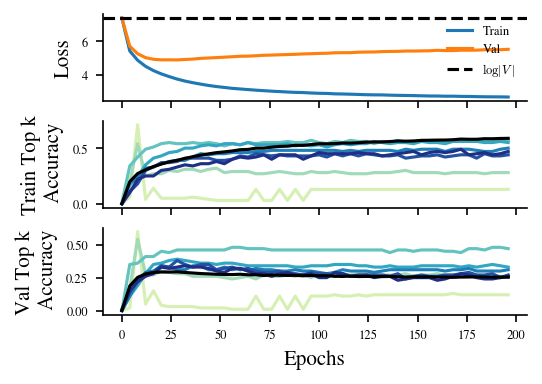

In [273]:
set_font_sizes(conf='tight')
epochs = metrics['step']/len(train_dataloader)
# index = np.linspace(3,config['seq_len']*0.3,5).astype(int)
index = [3,5,7,9,11,13,15]
colors = plt.get_cmap('YlGnBu')(np.linspace(0.2,0.9,len(index)))
fig , axes = create_fig(3,1,h=0.7)

ax = axes[0]
for lb in ['train','val']:
    loss = metrics[f'{lb}_loss']
    ax.plot(epochs,loss,label=lb.capitalize())
ax.axhline(np.log(vocab_size),ls='--',c='k',label=r'$\log |V\;|$')
ax.set_ylabel('Loss')
ax.legend(frameon=False)

for ax , lab in zip(axes[1:],['train','val']):
    av_acc = metrics[f'av_{lab}_acc']
    std_acc = metrics[f'std_{lab}_acc']
    acc = metrics[f'total_{lab}_acc']
    print(av_acc.shape)
    for i , idx in enumerate(index):
        m = av_acc[:, idx]
        s = std_acc[:, idx]
        col = colors[i]
        lb = rf'${idx}$' if lab == 'train' else None
        ax.plot(epochs,m,color=col,label=lb)
        # ax.fill_between(epochs,m-s,m+s,alpha=0.1,color=col)
    ax.plot(epochs,acc,c='k')
    # ax.legend(frameon=False,loc=(1,0.1),title=r'Seq index') if lab == 'train' else None
    ax.set_ylabel(f'{lab.capitalize()} Top k\n Accuracy')

ax.set_xlabel('Epochs')
# ax.set_xscale('log')

In [274]:
final_embedding_weigths = model.input_embeddings.embedding.weight.data.cpu().numpy()

eigvals = []
for emb in [initial_embedding_weight,final_embedding_weigths]:
    E = emb - np.mean(emb,axis=0,keepdims=True)
    M = E.T @ E / emb.shape[0]
    eigenvalues , eigenvectors = np.linalg.eigh(M)
    eigvals.append(eigenvalues)

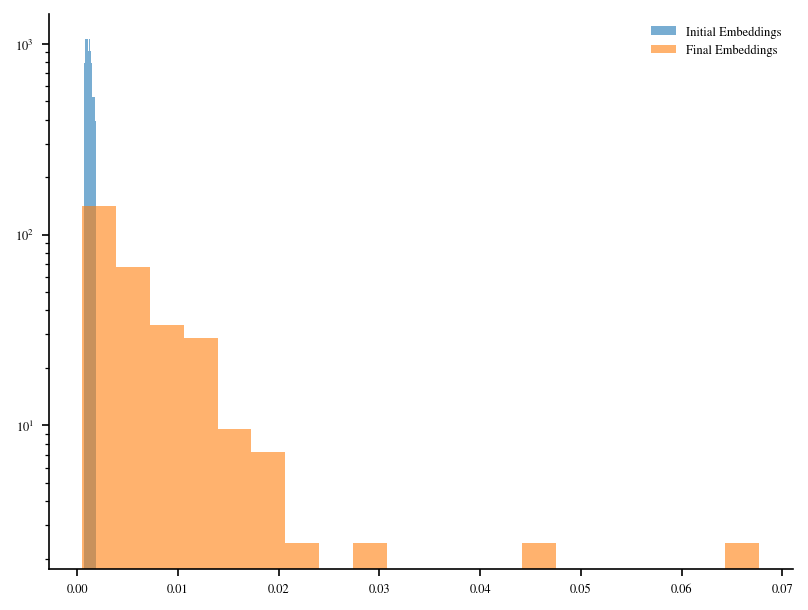

In [276]:
plt.hist(eigvals[0],bins=20,density=True,alpha=0.6,label='Initial Embeddings')
plt.hist(eigvals[1],bins=20,density=True,alpha=0.6,label='Final Embeddings')
plt.legend(frameon=False)
plt.yscale('log')
plt.show()


In [39]:

print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    idx = torch.cuda.current_device()
    print("Current GPU index:", idx)
    print("GPU name:", torch.cuda.get_device_name(idx))
print("CUDA build:", torch.version.cuda)
print("cuDNN enabled:", torch.backends.cudnn.is_available())

CUDA available: False
GPU count: 0
CUDA build: None
cuDNN enabled: False


# 3

3. Understanding Your SimpleTransformer for Next-Token Prediction

## Architecture Flow

```
Input: [SOS, tok1, tok2, tok3, PAD]  (batch, seq_len)
   ↓
┌─────────────────────────────────────────┐
│  Input Embeddings                       │
│  tokens → vectors                       │
│  (batch, seq_len) → (batch, seq_len, d_model)
└─────────────────────────────────────────┘
   ↓
┌─────────────────────────────────────────┐
│  Positional Encoding                    │
│  add position information               │
│  (batch, seq_len, d_model)             │
└─────────────────────────────────────────┘
   ↓
┌─────────────────────────────────────────┐
│  Attention Layer                        │
│  each position attends to all positions │
│  (batch, seq_len, d_model)             │
└─────────────────────────────────────────┘
   ↓
┌─────────────────────────────────────────┐
│  Output Linear Layer                    │
│  project to vocabulary                  │
│  (batch, seq_len, vocab_size)          │
└─────────────────────────────────────────┘
   ↓
Output: Logits for each position
```

## Output Interpretation

Your model outputs: `(batch, seq_len, vocab_size)`

- **For each position** in the sequence, the model predicts a probability distribution over the entire vocabulary
- Position `i` predicts what token should come **at position i** (not next to it!)
- The logits need to be compared with your labels using Cross-Entropy loss

## Training Setup

### Your Data Alignment:
```
Input:  [SOS, tok1, tok2, tok3, PAD]
Label:  [tok1, tok2, tok3, EOS, PAD]

Model predicts at each position:
Position 0: Given [SOS]           → should predict tok1
Position 1: Given [SOS, tok1]     → should predict tok2  
Position 2: Given [SOS, tok1, tok2] → should predict tok3
Position 3: Given [..., tok3]     → should predict EOS
Position 4: PAD (ignored in loss)
```

### Training Code Example:

```python
import torch.nn.functional as F

# Create model and dataset
model = SimpleTransformer(d_model=128, vocab_size=tokenizer.get_vocab_size(), 
                         seq_len=50, dropout=0.1)
train_dataset = NextTokenDataset(dataset, tokenizer, seq_len=50)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training loop
model.train()
for batch in train_loader:
    encoder_input = batch['encoder_input']     # (batch, seq_len)
    labels = batch['label']                    # (batch, seq_len)
    attention_mask = batch['attention_mask']   # (batch, 1, 1, seq_len)
    
    # Forward pass
    logits = model(encoder_input, attention_mask)  # (batch, seq_len, vocab_size)
    
    # Reshape for cross-entropy loss
    # CrossEntropyLoss expects: (batch * seq_len, vocab_size) and (batch * seq_len)
    logits_flat = logits.view(-1, logits.shape[-1])  # (batch*seq_len, vocab_size)
    labels_flat = labels.view(-1)                     # (batch*seq_len)
    
    # Compute loss (ignores padding automatically if you set ignore_index)
    loss = F.cross_entropy(logits_flat, labels_flat, 
                          ignore_index=tokenizer.token_to_id("[PAD]"))
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    print(f"Loss: {loss.item():.4f}")
```

## Key Points:

1. **Output Shape**: `(batch, seq_len, vocab_size)` contains logits (unnormalized probabilities)
2. **Loss Function**: Cross-Entropy Loss compares predicted distribution with actual next tokens
3. **Masking**: Padding tokens should be ignored in loss calculation using `ignore_index`
4. **During Inference**: Use `torch.argmax(logits, dim=-1)` or sampling to get predicted tokens

## Note on Your Attention Layer:

Your current attention allows **all positions to see all positions**. For proper next-token prediction, you typically want **causal masking** (each position can only see previous positions, not future ones). This prevents the model from "cheating" by looking at future tokens when predicting.